# Simultaneous - Tank Manifold DAE System Example

The following example is a DAE system adapted from {cite}`koch2024` describing a system of 4 interconnected tanks. The differential states $x_0, ..., x_3$ describe the fluid heights in the tanks and the algebraic variables $y_1, ..., y_4$ denote the flow rate between tanks. A pump sets the flow rate of algebraic variable $y_0$ as a function of the fluid heights $x_0$ and $x_3$. The flow in $y_2$ is reversible. The fluid heights in $x_0$ and $x_1$ are constrained at all times.

The system is shown graphically below:

![FourTank_Koch](../images/FourTank_Koch2024.png)

The DAE describing the evolution of this system in time is given by:

$$
\begin{align}
\frac{dx_0}{dt} &= \frac{1}{\phi_0(x_0)}(y_1 - y_3) \tag{1} \\
\frac{dx_1}{dt} &= \frac{1}{\phi_1(x_1)}(y_2) \tag{2} \\
\frac{dx_2}{dt} &= \frac{1}{\phi_2(x_2)}(y_3 - y_4) \tag{3} \\
\frac{dx_3}{dt} &= \frac{1}{\phi_3(x_3)}(y_4 - y_0) \tag{4} \\
x_0(t) = x_1(t), \quad y_0(t) &= y_1(t) + y_2(t), \quad y_4(t) = a_2\sqrt{x_2(t)} \tag{5} \\
y_0(t) &= C_{pump}x_0x_3, \quad y_3(t) = a_1\sqrt{x_0(t)} \tag{6} \\
y_0(t), y_1(t), y_3(t), y_4(t) &\geq 0 \tag{7}
\end{align}
$$


Where, $\phi_i(x_i)$ describes the area-height profile of the tanks, which is defined by their shape. Let all the area profiles be constant: $\phi_0(x_0)=\frac{1}{10}$, $\phi_1(x_1)=\frac{1}{2}$ $\phi_2(x_2)=2$, $\phi_3(x_3)=10$. The discharge coefficients, $a_1$ and $a_2$, are set at $\frac{1}{10}$, while the pump discharge coefficient, $C_{pump}$, is set at $\frac{1}{5}$. 


In this example, assume the expressions in $(6)$ are unknown. Thus, we would like to learn a neural network mapping from the obsereved height variables $x(t)$ to the unknown flowrates in $(3)$, i.e. $f_{NN}: x(t) \rightarrow (y_0(t), y_3(t))^T$. Therefore, (6) can be rewritten as:

$$
\begin{align}
z(t) = (y_3(t), y_0(t))^T &= f_{NN}(x(t), \theta)  \tag{8} \\
\end{align}
$$

**NOTE:** This example uses the high-level `HybridDAE` wrapper, whose `.fit()` and `.predict()` methods orchestrate the full smoother, pretrain, train, and inference pipeline. To run each stage explicitly, call the stage functions directly as documented in the [API reference](../api/hybrid_dae.md).

Let's start with the required imports.

In [1]:
%matplotlib inline

import logging
import jax
import numpy as np
import pyomo.environ as pyo
import pyomo.dae as dae
import matplotlib.pyplot as plt

from sindae.problem import ProblemDefinition
from sindae.nn_utils import SimpleMLP
from sindae.data_utils import InstanceData
from sindae import generate_data, HybridDAE
from sindae.algorithms.smoother import SmootherConfig
from sindae.algorithms.pretrain import PretrainConfig
from sindae.algorithms.simultaneous.train import SimultaneousConfig
from sindae.solvers import SolverConfig
from sindae.plot_utils import plot_instance_data

jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logging.getLogger('pyomo').setLevel(logging.ERROR)
logging.getLogger('cyipopt').setLevel(logging.WARNING)
logger = logging.getLogger(__name__)

## Defining A Problem

Before using SiNDAE's solution approaches, you should formulate the DAE you are solving by defining a `ProblemDefinition` class. The problem definition class requires the implementation of 3 methods: `build_trajectory(self, block: pyo.Block, traj_idx: int)` which adds the DAE formulation and constraints to a Pyomo Block, `get_input_vars(self, block: pyo.Block, t)` which returns the list of Pyomo Vars fed into the NN at time $t$, and `get_output_vars(self, block: pyo.Block, t)` which returns a list of Pyomo Vars output by the NN at time $t$. 

With these methods in mind, we can define our `FourTankProblem` by inheriting from `ProblemDefinition`.

Define the DAE problem class and the required `ProblemDefinition` methods. The `build_trajectory()` defines the DAE system, algebraic constraints, and auxiliary constraints / variables using the Pyomo modelling language. For this example problem, we know the true dynamics of our problem (i.e. the $y_0$ and $y_3$ dynamics), so the `true_constraints()` can be defined, allowing synthetic data generation.

In [2]:
class FourTankProblem(ProblemDefinition):
    def __init__(self,
                 ## Additional Args ##
                 params,
                 ## ProblemDefinition Args ##
                 ics, 
                 input_dim, 
                 z_dim, 
                 t_span, 
                 nfe, 
                 ncp, 
                 obs_times = None, 
                 obs_values = None, 
                 obs_dim = None, 
                 aux_vars_dim = None
                 ):
        
        super().__init__(ics, input_dim, z_dim, 
                         t_span, nfe, ncp, obs_times, 
                         obs_values, obs_dim, aux_vars_dim)

        self.params = params 


    def build_trajectory(self, block, traj_idx):
        t0, _ = self.t_span
        x0    = self.ics[traj_idx]
        p     = self.params
        phi   = p['phi']

        block.t    = dae.ContinuousSet(bounds=self.t_span) 
        block.x    = pyo.Var(block.t, range(self.input_dim), initialize=10.0)
        block.z    = pyo.Var(block.t, range(self.z_dim)) # z is the RHS of the equations to be learned by a NN
        block.y    = pyo.Var(block.t, range(self.aux_vars_dim))
        block.dxdt = dae.DerivativeVar(block.x, wrt=block.t)
        
        ## Differential Equations ##
        @block.Constraint(block.t, range(self.input_dim))
        def diffeq(b, t, s):
            y = [b.y[t, j] for j in range(self.aux_vars_dim)]
            if s == 0:
                # Eqn (1)
                return b.dxdt[t, 0] == (1.0 / phi[0]) * (y[1] - y[3])
            elif s == 1:
                # Eqn (2)
                return b.dxdt[t, 1] == (1.0 / phi[1]) * y[2]
            elif s == 2:
                # Eqn (3)
                return b.dxdt[t, 2] == (1.0 / phi[2]) * (y[3] - y[4])
            else:
                # Eqn (4)
                return b.dxdt[t, 3] == (1.0 / phi[3]) * (y[4] - y[0])


        ## Algebraic constraints ##
        
        # Eqn (5-1)
        @block.Constraint(block.t)
        def height_req(b, t):  
            return b.x[t, 0] == b.x[t, 1]
        
        # Eqn (5-2)
        @block.Constraint(block.t)
        def flow_balance(b, t): 
            return b.y[t, 0] == b.y[t, 1] + b.y[t, 2]

        # Eqn (5-3)
        @block.Constraint(block.t)
        def dis4(b, t):        
            return b.y[t, 4] == p['a2'] * pyo.sqrt(b.x[t, 2])

        # Eqn (6-1)
        @block.Constraint(block.t)
        def pump(b, t):        
            return b.y[t, 0] == b.z[t, 0] # z is the RHS of the equations to be learned by a NN

        # Eqn (6-2)
        @block.Constraint(block.t)
        def dis3(b, t):        
            return b.y[t, 3] == b.z[t, 1] # z is the RHS of the equations to be learned by a NN

        # Eqn (7)
        @block.Constraint(block.t, range(self.aux_vars_dim))
        def flow_lb(b, t, j):
            if j == 2:
                return pyo.Constraint.Skip
            return b.y[t, j] >= 0


        # Initial conditions
        for j in range(1, self.input_dim):
            block.x[t0, j].fix(float(x0[j]))

        # Clamp y_1 at t_0 to avoid under-determined algebraic system at the initial collocation point.
        @block.Constraint()
        def clamp_u1(b): 
            return b.y[t0, 1] == b.y[t0, 0]


    ## Ground Truth ##
    def add_true_output_constraints(self, block: pyo.Block) -> None:
        a1 = self.params['a1']
        cp = self.params['pump_coef']

        @block.Constraint(block.t, range(self.z_dim))
        def true_z(b, t, k):
            if k == 0:
                return b.z[t, 0] == cp * b.x[t, 0] * b.x[t, 3]
            else:
                return b.z[t, 1] == a1 * pyo.sqrt(b.x[t, 0])
            

    def get_input_vars(self, block, t):  
        return [block.x[t, j] for j in range(self.input_dim)]

    def get_output_vars(self, block, t): 
        return [block.z[t, k] for k in range(self.z_dim)]

    def get_aux_vars(self, block, t):    
        return [block.y[t, k] for k in range(self.aux_vars_dim)]

The parameters of this problem are given by the following:

In [3]:
FT_PARAMS = {
    'a1':        0.1,                   # a_1 = 1/10
    'a2':        0.1,                   # a_2 = 1/10
    'pump_coef': 0.2,                   # C_{pump} = 1/5
    'phi':       [0.1, 0.5, 2.0, 10.0], # phi_i = [1/10, 1/2, 2, 10]
}

SEED = 0

Initial conditions for sample trajectories should also be defined. For this example, the $x_0=x_1$ constraint in $(5)$ should be reflected in the ICs. These are the *training* ICs. These will be used for data generation from the ground truth model (since this is a known example), and as state variable initial conditions for the differential system.

In [4]:
## Initial Conditions ##
FT_ICS = np.array([
    [0.75, 0.75, 2.50, 0.60], # traj_0: x_t0 = [x_1, x_2, x_3, x_4]
    [3.10, 3.10, 1.50, 0.50], # traj_1
    [0.90, 0.90, 1.80, 1.10], # traj_2
])

Next, define the observed variable state dimension, $x(t)$, the number of NN modeled variables, $z(t)$, and the number of algebraic variables, $y(t)$.

In [5]:
## Problem dimensions ##
FT_STATE_DIM = 4    # NN input dim
FT_Z_DIM     = 2    # NN output dim
FT_ALG_DIM   = 5    # Algebraic variable dim 


The timespan over which the model should be solved.

In [6]:
## Time span ##
T_SPAN = (0, 400)

In this example, the training data will be generated from a ground truth model with added noise. Therefore, the number of discretization points at which the ground truth model is solved should be specified in the problem definition. Using `generate_data()` will solve the model with the `add_true_output_constraints()` at this discretization scheme. Once the data is generated, the discretization scheme can (and will) be updated for training.

In [7]:
## Discretization for data generation with true model ##
NFE_DATA  = 40
NCP_DATA  = 3

Now we can define the problem instance.

In [8]:
## Define the problem instance ##
problem = FourTankProblem(
    # Additional args
    params=FT_PARAMS,
    # Problem definintion args
    ics=FT_ICS,
    input_dim=FT_STATE_DIM,
    z_dim=FT_Z_DIM,
    t_span=T_SPAN,
    nfe=NFE_DATA, 
    ncp=NCP_DATA,
    obs_dim=FT_STATE_DIM,
    aux_vars_dim=FT_ALG_DIM
    )


## Generating training Data

With the problem defined, we can use the `generate_data()` function to generate the synthetic training data.

In [9]:
## Added noise standard deviation ##
NOISE_STD   = np.array([0.5, 0.5, 0.25, 0.05])

## Ground truth observation frequency ##
OBS_EVERY = 4

In [10]:
print('=== 1. Generating data ===')
true_data: InstanceData = generate_data(
    problem=problem, 
    noise_std=NOISE_STD, 
    obs_every=OBS_EVERY, 
    seed=SEED,
)

=== 1. Generating data ===


generate_data: ok / optimal


## Step 1 - Defining the Neural Network

Before pretraining, the NN used to estimate the $z(t)$ terms should be defined. SinDAE, comes equipped with a `SimpleMLP` class as an equinox MLP implementation, which we will be using for this example. To set up your own NN architecture, see [Neural Network Utilities](../api/nn_utils.md).

In [11]:
## Define the NN ##
mlp = SimpleMLP(
    in_size=problem.input_dim,
    out_size=problem.z_dim,
    widths=[32, 32],
    activations=[jax.nn.tanh] * 2,
    key=jax.random.PRNGKey(SEED),
)

## Step 2 - Configure the Pipeline Stages

The `HybridDAE` wrapper runs the full pipeline: the smoother (a data-fitting NLP with $z(t)$ free), supervised pretraining of the network on the smoother output, and the simultaneous training solve. Each stage is configured with its own config dataclass, and the NLP solver options are shared by the fit-time solves.

As in the low-level workflow, the training discretization can differ from the grid used for data generation, so we update the problem's `nfe` / `ncp` before fitting.

In [12]:
## Training discretization (may differ from the data-generation grid) ##
NFE_TRAIN = 20
NCP_TRAIN = 3

problem.nfe = NFE_TRAIN
problem.ncp = NCP_TRAIN

## Smoother stage ##
SMOOTH_COEF = 10.0
smoother_config = SmootherConfig(smooth_coef=SMOOTH_COEF)

## Pretraining stage ##
pretrain_config = PretrainConfig(
    epochs=200,
    batch_size=32,
    reg_coef=0.01,
)

## Simultaneous training stage ##
simul_cfg = SimultaneousConfig(
    use_gbm=False,
    reg_coef=0.01,
)

## POUNCE solver options (shared by the fit-time solves) ##
solver_options = SolverConfig(
    tol=1e-6,
    max_iter=1000,
    hessian_approximation='exact',   # or 'limited-memory' (L-BFGS)
)

## Step 3 - Fit the Hybrid Model

Assemble the stage configs into a `HybridDAE` and call `fit`. This runs smoother, pretrain, and simultaneous training in sequence; the training solve's termination condition lands on `model.termination`, and every intermediate stays reachable as an attribute (`model.smoother_data`, `model.trained_data`, ...). Passing `metrics=[...]` prints per-trajectory fit metrics after training.

In [13]:
model = HybridDAE(
    method="simultaneous",
    nlp_solver="pounce",
    linear_solver="feral",
    net=mlp,
    smoother=smoother_config,
    pretrain=pretrain_config,
    train=simul_cfg,
    solver_options=solver_options,
    unfix_io=True,
)

print('=== Fitting hybrid model (simultaneous) ===')
model.fit(problem, metrics=["rmse"], tee=True)
print(f'training termination: {model.termination}')

## Intermediates stay reachable after fit ##
smoother_data = model.smoother_data
trained_data  = model.trained_data

=== Building smoother for 3 trajectories (smooth_coef=10.0) ===


=== Fitting hybrid model (simultaneous) ===


  Smoother: ok / optimal


=== Building simultaneous (expr-writing) model for 3 trajectories ===


=== Solving simultaneous model (pounce, expr-writing) ===


...

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  50  3.0132719e-01 1.83e-07 2.29e-09   -5.7 8.75e-04      - 1.00e+00 1.00e+00h  1


  51  3.0132716e-01 3.76e-08 1.10e-09   -7.0 7.00e-04      - 1.00e+00 1.00e+00h  1

Timing Statistics:
OverallAlgorithm....................:         318.046s
 InitializeIterates.................:           0.971s
 UpdateHessian......................:         199.660s
 OutputIteration....................:           0.016s
 UpdateBarrierParameter.............:           0.017s
 ComputeSearchDirection.............:         115.595s
 ComputeAcceptableTrialPoint........:           0.682s
 AcceptTrialPoint...................:           0.000s
 CheckConvergence...................:           0.061s
LinearSystemFactorization...........:         113.363s
LinearSystemBackSolve...............:           2.576s
QualityFunctionSearch...............:           0.000s
TotalFunctionEvaluations............:         201.237s
 ObjectiveFunctionEvaluations.......:           0.003s
 ObjectiveGradientEvaluations.......:           0.002s
 ConstraintEvaluations..............:           0.545s
 ConstraintJacobi

  pounce: ok / optimal


=== Simultaneous solve complete ===


=== Per Trajectory Metrics ===
RMSE: 
╒════════╤══════════╤══════════╤══════════╤═══════════╕
│        │      x_0 │      x_1 │      x_2 │       x_3 │
╞════════╪══════════╪══════════╪══════════╪═══════════╡
│ traj_0 │ 0.444854 │ 0.447385 │ 0.245025 │ 0.0544459 │
├────────┼──────────┼──────────┼──────────┼───────────┤
│ traj_1 │ 0.470596 │ 0.434468 │ 0.26533  │ 0.0592215 │
├────────┼──────────┼──────────┼──────────┼───────────┤
│ traj_2 │ 0.64294  │ 0.558915 │ 0.247066 │ 0.0553875 │
╘════════╧══════════╧══════════╧══════════╧═══════════╛
training termination: optimal


## Plot Results

<Figure size 1920x1440 with 0 Axes>

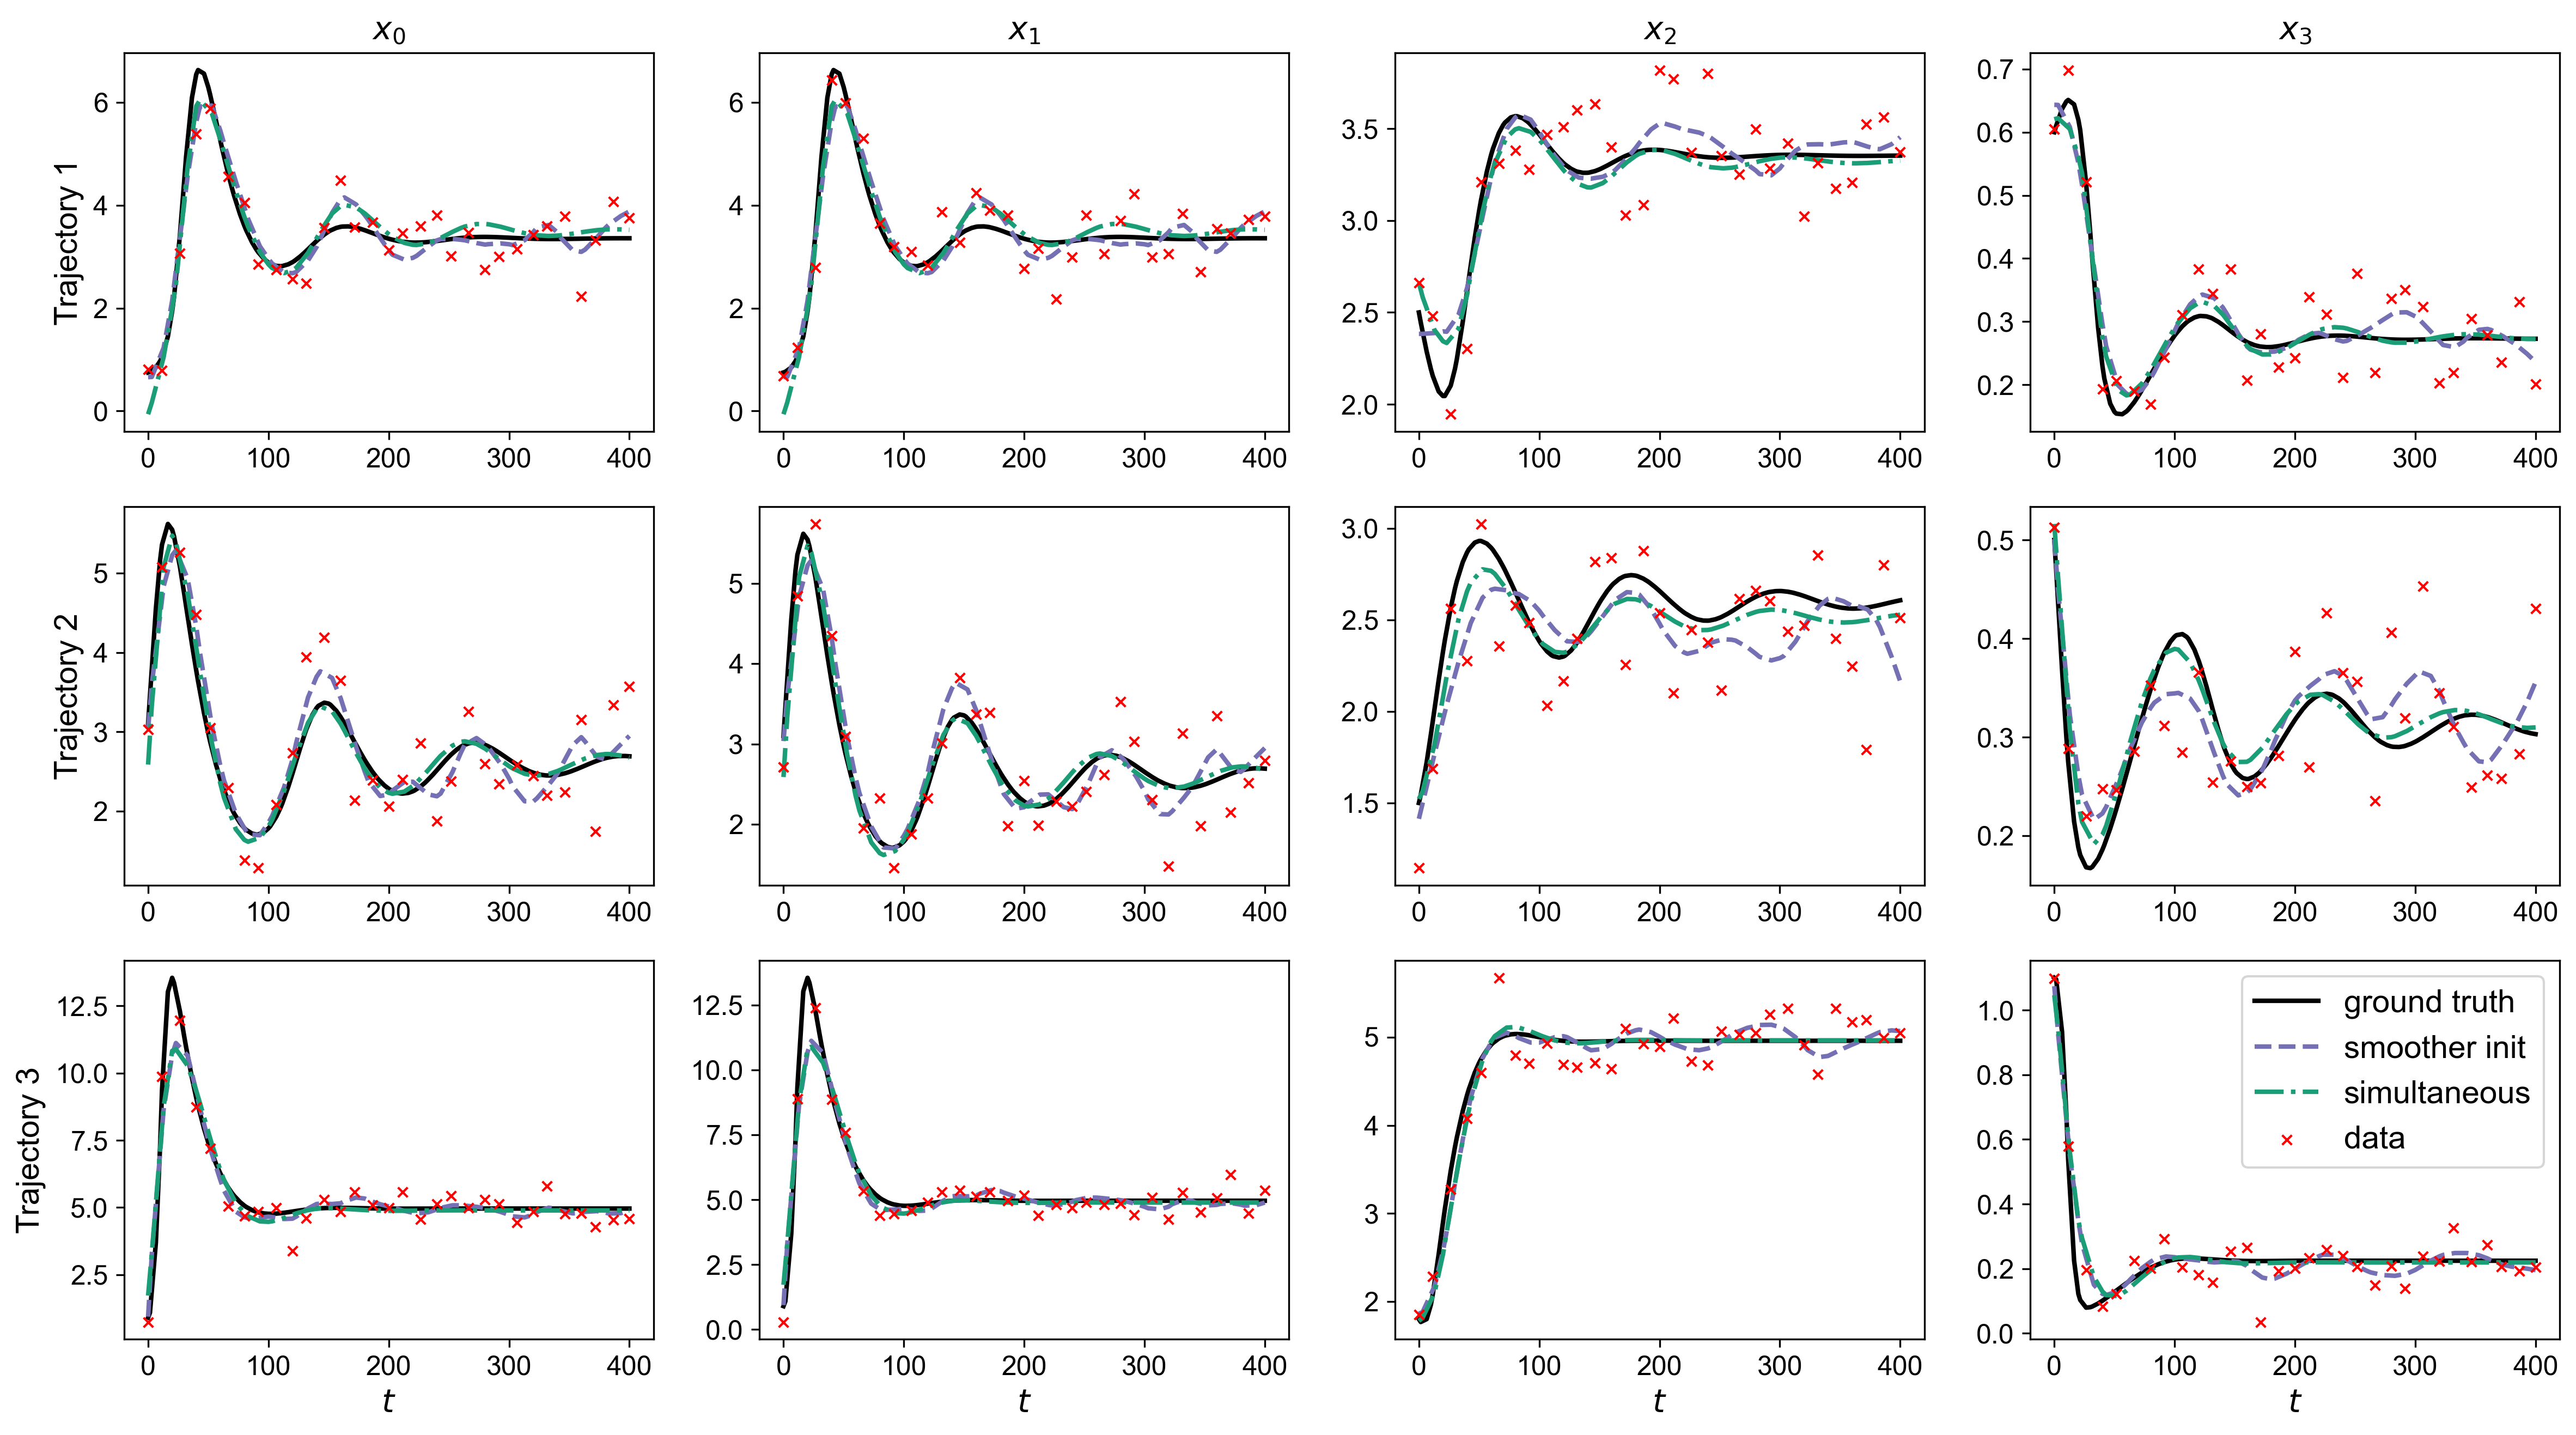

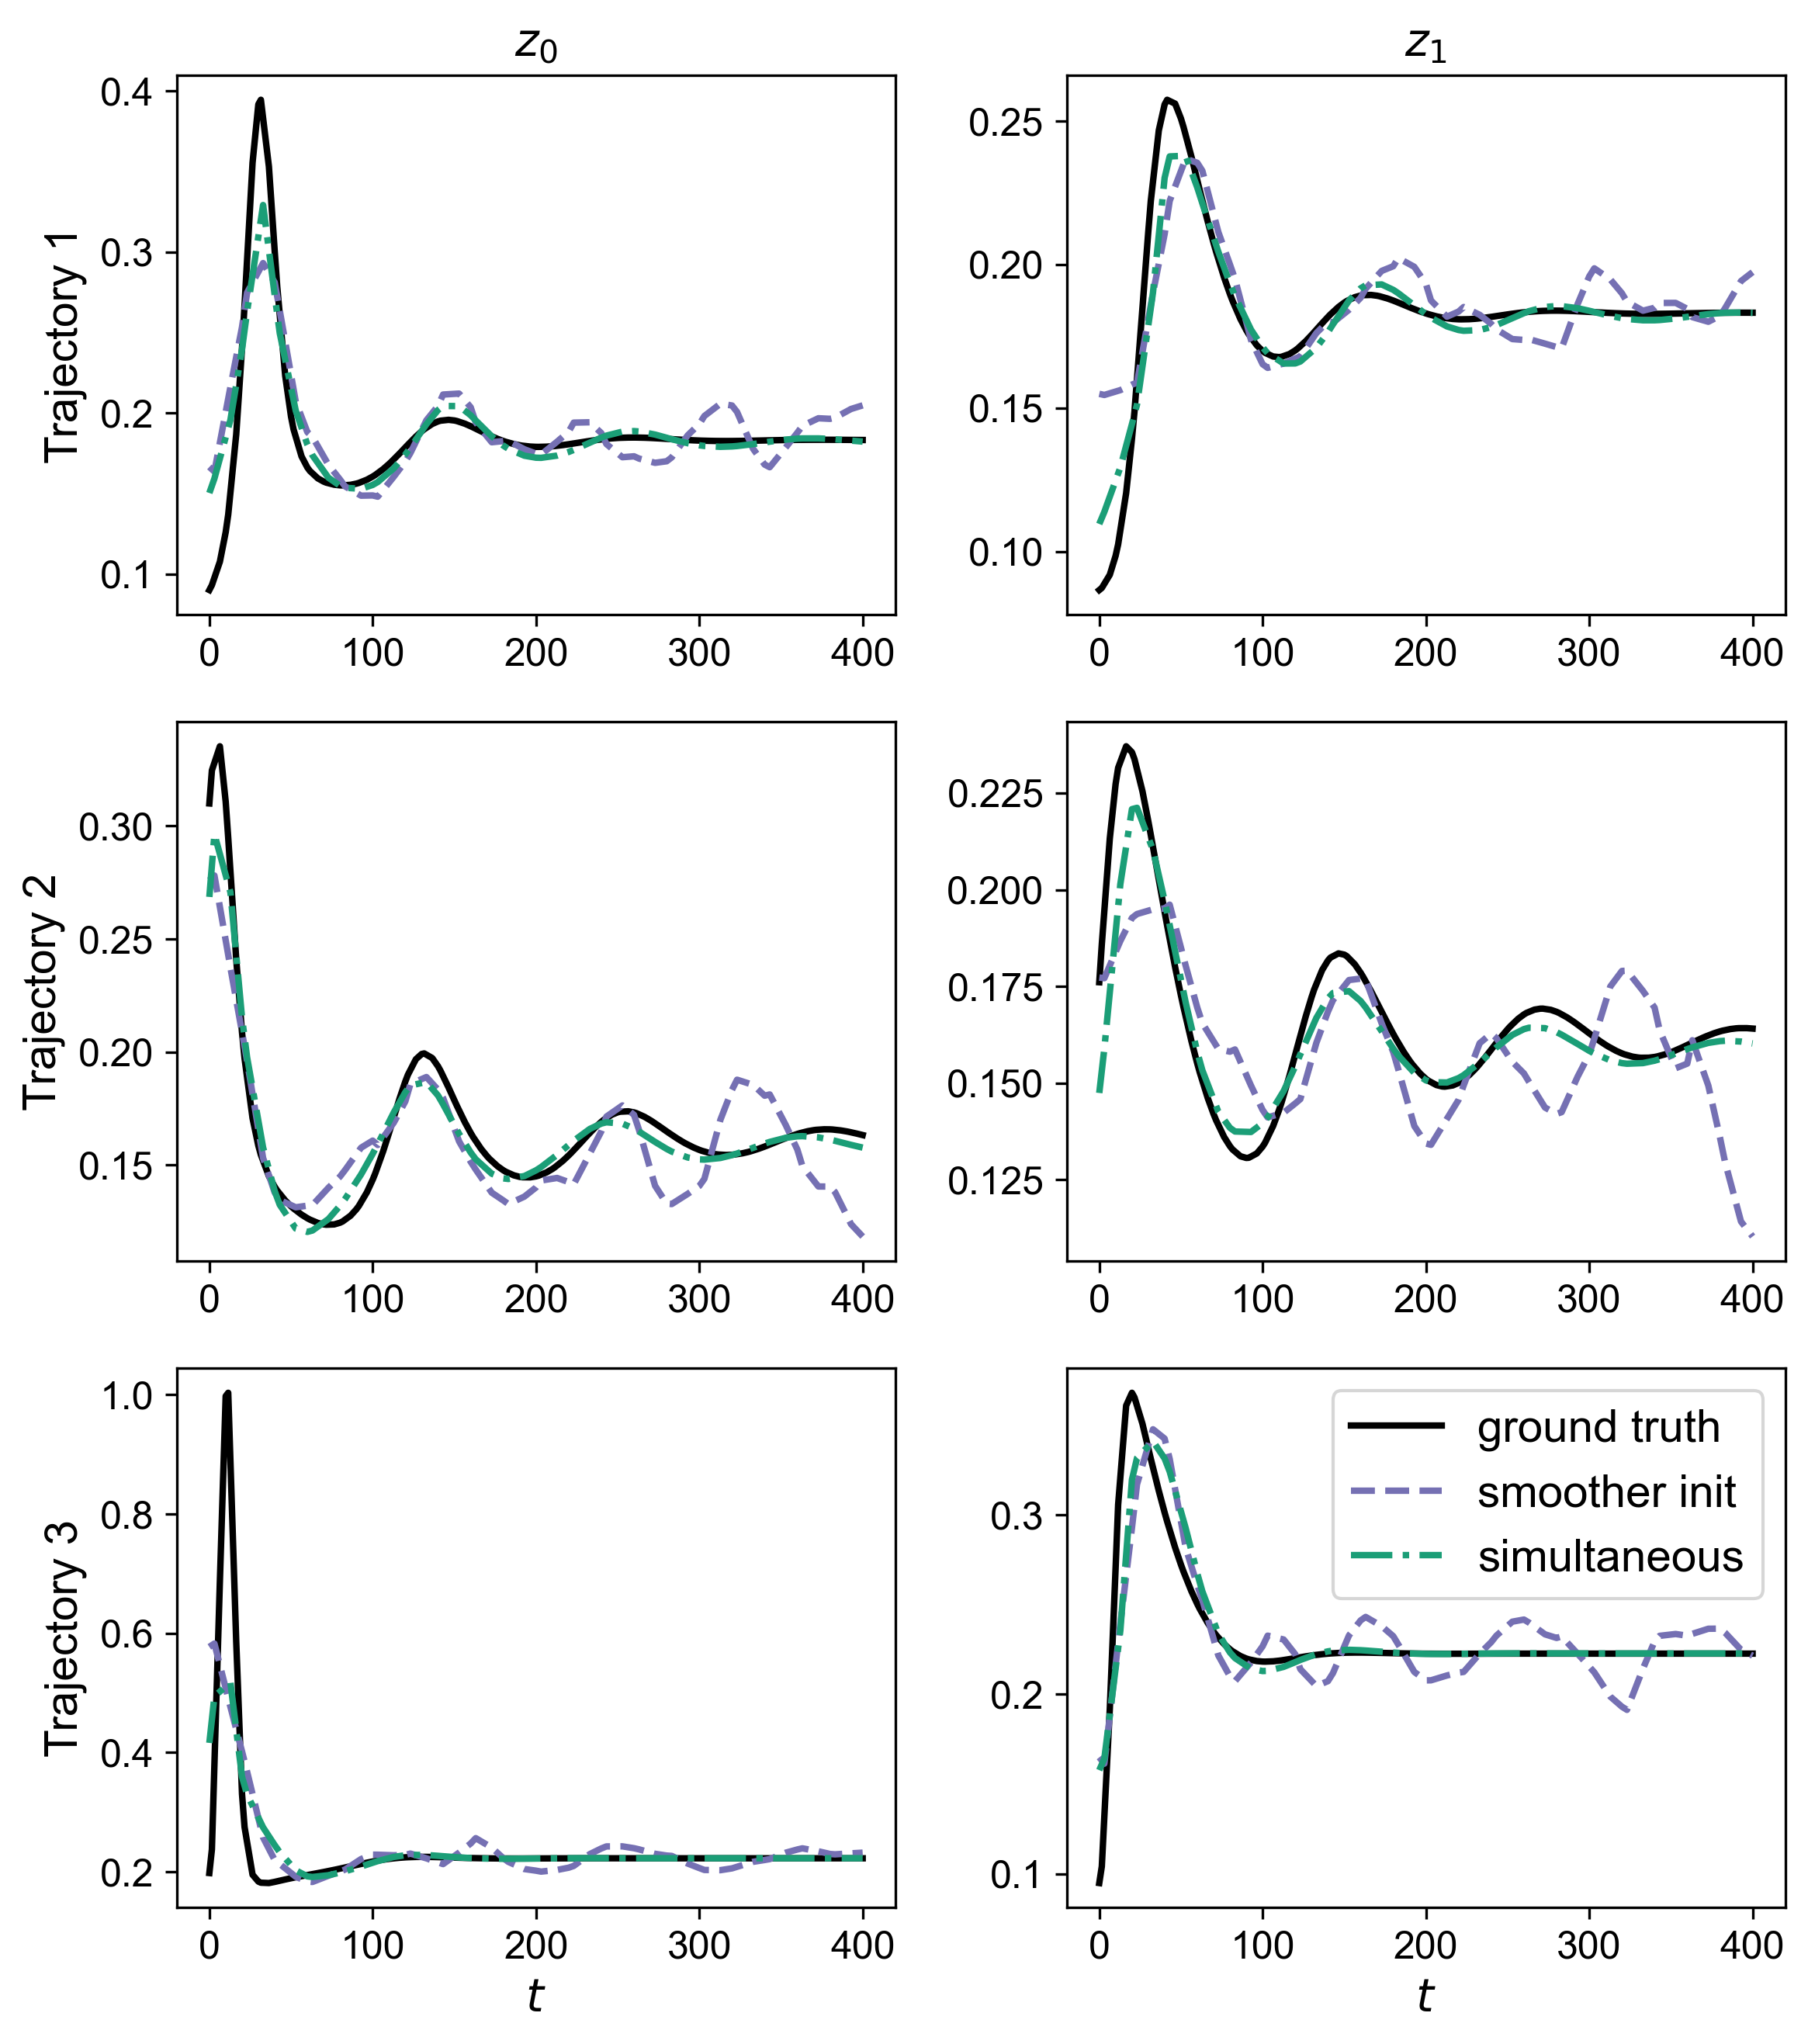

In [14]:
STATE_NAMES  = ['$x_0$', '$x_1$', '$x_2$', '$x_3$']
OUTPUT_NAMES = ['$z_0$', '$z_1$']

datasets = [
        (true_data,     'ground truth',  {'color': 'black', 'ls': '-'}),
        (smoother_data, 'smoother init', {'color': 'C2',    'ls': '--'}),
        (trained_data,  'simultaneous',  {'color': 'C0',    'ls': '-.'}),
    ]

plt.figure()
fig_x, _ = plot_instance_data(
    datasets=datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    obs_times=problem.obs_times, obs_values=problem.obs_values,
    obs_names=STATE_NAMES, groups=['inputs'], legend_placement='last',
)
fig_z, _ = plot_instance_data(
    datasets=datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    groups=['outputs'], legend_placement='last',
)

plt.show()

## Step 4 - Inference using Trained Model

Now that the hybrid model is trained, we can call `model.predict()` to predict trajectories given different initial conditions.

Accordingly, we can set new initial conditions for a new instance of the four tank problem defined above. Other parameters including: the number of discretization points, the number of collocation points, the time span, or the mechanistic parameters can also be altered before doing inference.

In [15]:
## Validation Trajectory ICs##
FT_VAL_ICS = np.array([[1.10, 1.10, 2.40, 0.90]])

# can also edit the discretization for demonstration
NFE_VAL = 20 
NCP_VAL = 2

val_problem = FourTankProblem(
    params=FT_PARAMS,
    ics=FT_VAL_ICS,         # Validation ICs
    input_dim=FT_STATE_DIM,
    z_dim=FT_Z_DIM,
    t_span=T_SPAN,
    nfe=NFE_VAL,            # Validation
    ncp=NCP_VAL,            # Validation
    obs_dim=FT_STATE_DIM,
    aux_vars_dim=FT_ALG_DIM
    )

Since we know the ground truth dynamics for this problem, we can generate a ground truth trajectory to compare the inference result to. Of course, when making predictions on real problems, this is not usually possible. Here, the ground truth curve in intended to serve as a visual reference for hybrid model predictive capacity once trained.

A ground truth curve can be generated using the `generate_data()` function with `noise_std` set to 0 (for each dependent variable).

In [16]:
## Ground truth for visualisation ##
val_truth = generate_data(
    problem=val_problem, 
    noise_std=np.zeros(4),  # No added noise = ground truth
    obs_every=1,            # Observations = ground truth sampling
    seed=SEED)

generate_data: ok / optimal


`model.predict()` embeds the trained network in the new problem and solves the inference NLP. It reuses the normalization statistics captured during `fit` (from the smoother stage), so the network is evaluated in the space it was trained in, and returns the predicted trajectories as an `InstanceData` object directly.

By default, `predict` enforces the NN equality as a hard constraint (`slack_coef=0.0`). If that leads to convergence difficulties, a small `slack_coef` adds l1 slack to loosen the constraint within reason. See [Inference](../api/inference.md) for more details.

In [17]:
## Predict the validation trajectory with the trained model ##
val_results = model.predict(val_problem, slack_coef=1e-5)

=== Building inference model for 1 trajectories (slack_coef=1e-05) ===


=== Solving inference model ===


  Inference: ok / optimal


Plotting similar to the training results above.

<Figure size 1920x1440 with 0 Axes>

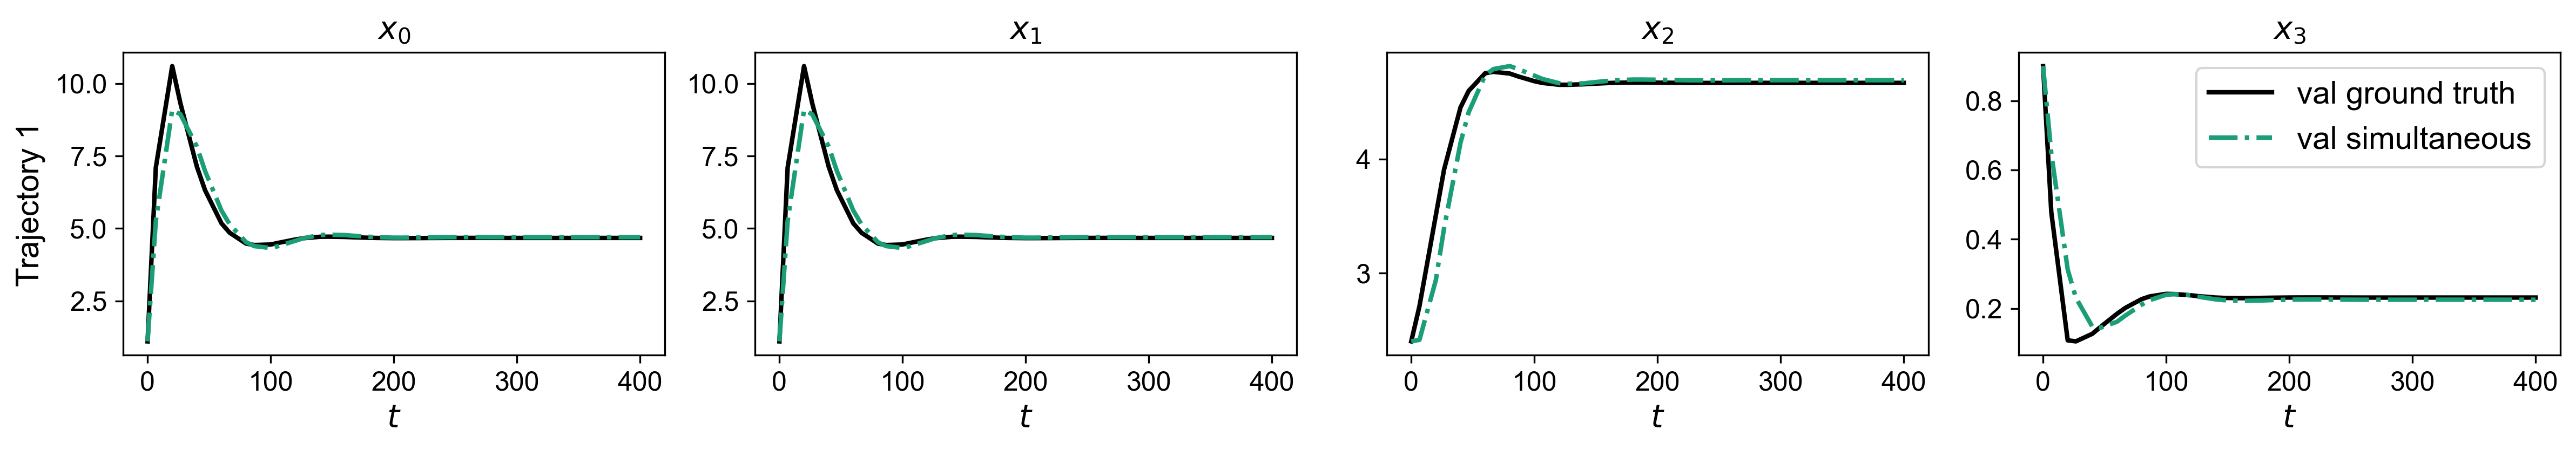

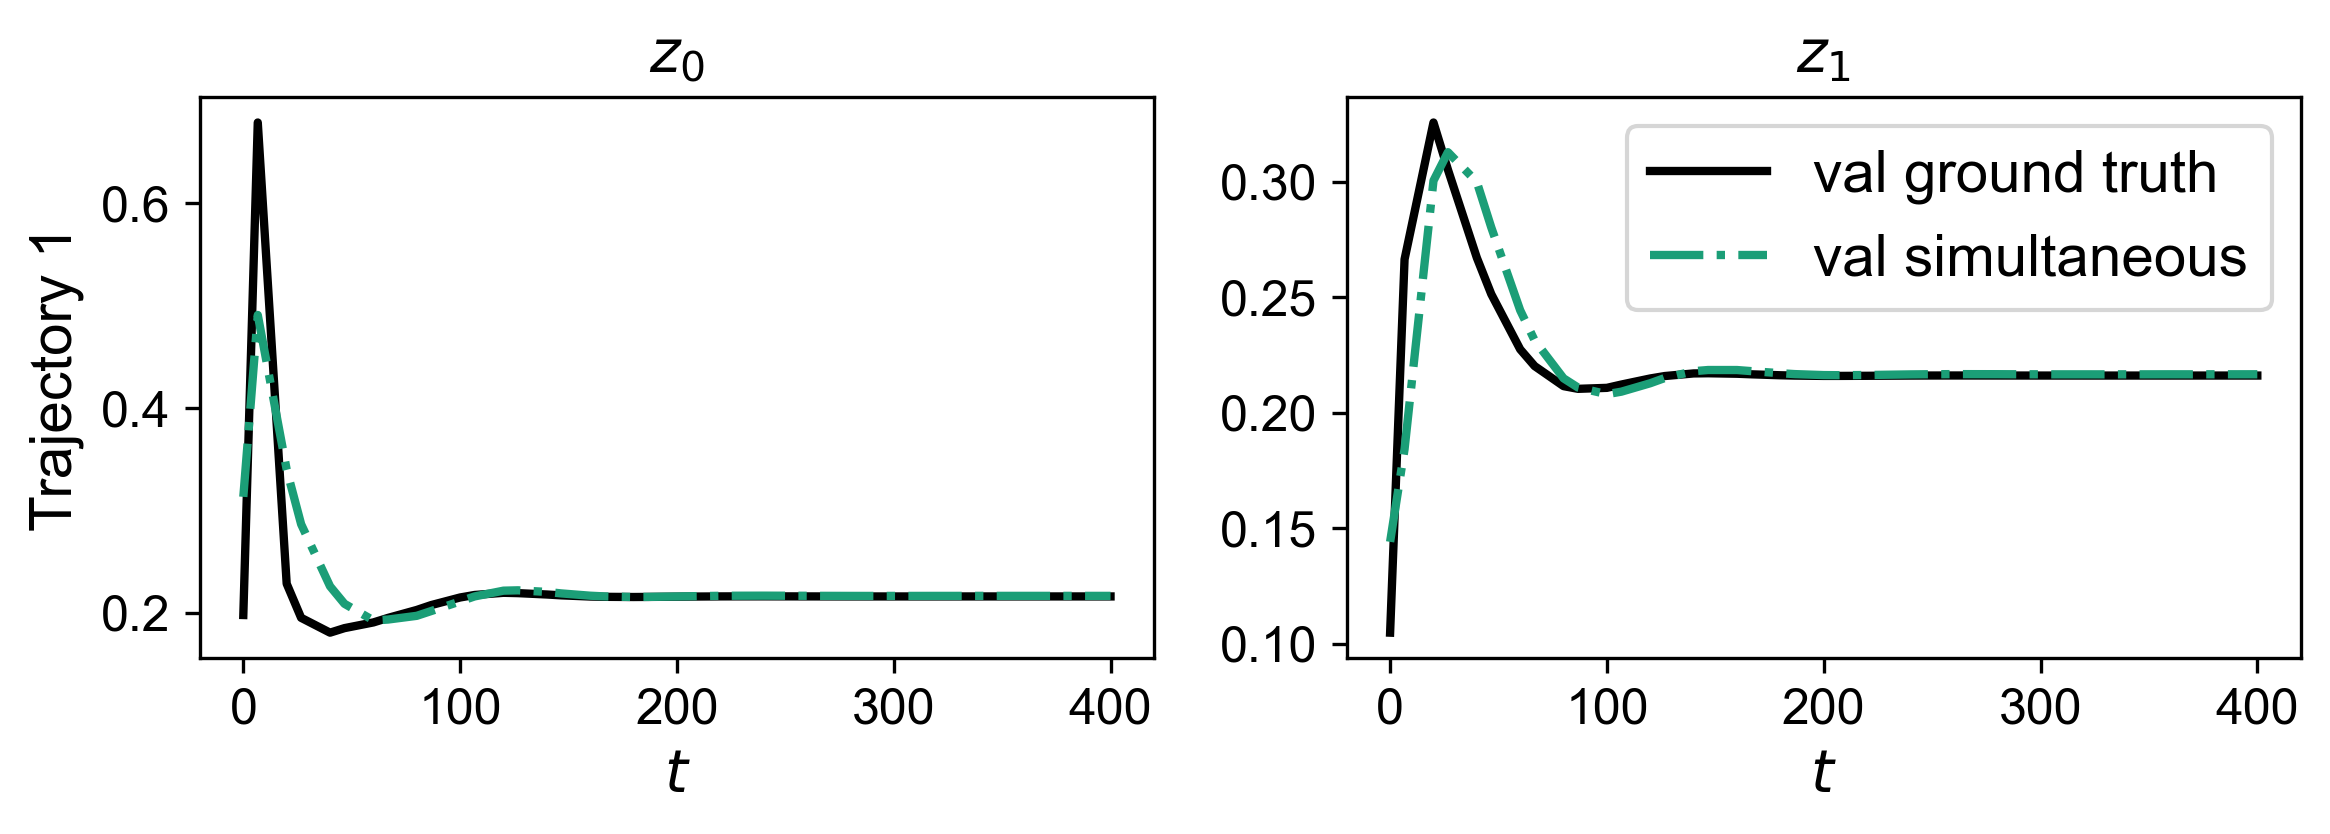

In [18]:
val_datasets = [
        (val_truth,     'val ground truth',  {'color': 'black', 'ls': '-'}),
        (val_results,   'val simultaneous',  {'color': 'C0',    'ls': '-.'}),
    ]

plt.figure()
fig_x, _ = plot_instance_data(
    datasets=val_datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    obs_names=STATE_NAMES, groups=['inputs'], legend_placement='last',
)
fig_z, _ = plot_instance_data(
    datasets=val_datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    groups=['outputs'], legend_placement='last',
)

plt.show()

{cite}`lueg2025simultaneous`